# Projection matrix generation for SPECT with GATE 10 - Example of 3D Jaszczak Phantom

This notebook provides a practical demonstration of **projection matrix generation for SPECT using GATE 10**.  
A 3D water based Jaszczakn Phantom is used


# General Definitions

*The notebook expects the project files to be available in PROJECT_PATH*

In [1]:
PROJECT_PATH = "./"
OUTPUT_BASE = PROJECT_PATH

In [2]:
from pathlib import Path

required_files = [
    f"{PROJECT_PATH}/GATE10.py",
]

for f in required_files:
    if not Path(f).exists():
        raise FileNotFoundError(f"Required file not found: {f}")

print("All required files found.")

All required files found.


In [ ]:
!pip install --upgrade pip

In [ ]:
!pip install --upgrade opengate

In [ ]:
!pip install pydicom opengate uproot awkward tensorflow scikit-image

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import uproot, awkward as ak
import tensorflow as tf
import time
import sys
sys.path.append(PROJECT_PATH)
from scipy.ndimage import convolve
import os
import pickle as pk
import pydicom
from tqdm import tqdm  # optional: for progress bar
from skimage.transform import radon

import GATE10

def writedata(df,fname):
    pk.dump(df,open(fname,'wb'))
    return

def readdata(fname):
    return pk.load(open(fname,'rb'))


def printProgressBar(i,max,postText):
    n_bar =40 #size of progress bar
    j= i/max
    sys.stdout.write('\r')
    sys.stdout.write(f"[{'=' * int(n_bar * j):{n_bar}s}] {int(100 * j)}%  {postText}")
    sys.stdout.flush()



def smear(image, d):
    result = np.copy(image)  # Create a copy of the input image to store the result

    # Create a kernel of ones with a size of (2*d+1) for convolution
    kernel = np.ones((2*d + 1, 2*d + 1))

    # Use convolution to compute the sum of the neighborhood for each cell
    sums = convolve(image, kernel, mode='constant', cval=0)

    # Count the number of neighbors for each cell
    num_neighbors = convolve(np.ones_like(image), kernel, mode='constant', cval=0)

    # Compute the local average by dividing the sum by the number of neighbors
    local_average = sums / num_neighbors



    # Replace each cell with its corresponding local average
    result = local_average


    return result



In [4]:
def load_dicom(file_path):
    """
    Loads a DICOM file containing emission data and returns the image as a NumPy array
    along with metadata in a dictionary.

    Args:
        file_path (str): Full path to the DICOM file.

    Returns:
        tuple: (image_array, metadata_dict)
            - image_array (np.ndarray): The image pixel data.
            - metadata_dict (dict): Dictionary of DICOM metadata.
    """
    if not os.path.isfile(file_path):
        raise FileNotFoundError(f"File '{file_path}' not found.")

    try:
        dicom_data = pydicom.dcmread(file_path)

        # Extract pixel data to numpy array
        image_array = dicom_data.pixel_array

        # Extract metadata to dictionary
        metadata_dict = {}
        for elem in dicom_data:
            if elem.VR != 'SQ':  # Skip sequences to avoid complexity
                metadata_dict[elem.keyword or elem.tag] = elem.value

        return image_array, metadata_dict

    except Exception as e:
        print(f"Error reading DICOM file: {e}")
        return None, None


# Create 3D Jaszczak Phantom

In [5]:
ndim=nrays=128
nangle=120
phantom_width=200 #mm
PIXEL_SIZE = phantom_width/ndim
print(f'PIXEL_SIZE = {PIXEL_SIZE} mm')
scale=1

PIXEL_SIZE = 1.5625 mm


In [6]:
def add_cylinder_to_world(
    world: np.ndarray,
    r_mm: float,
    h_mm: float,
    x0: float, y0: float, z0: float,
    axis: str = "z",
    voxel_size_mm: float = 4.0,
    value: float = 1.0,
    normalize: bool = True,
) -> np.ndarray:
    nx, ny, nz = world.shape

    # symmetric voxel-center coordinates (works for odd and even ndim)
    x_coords = (np.arange(nx) - (nx - 1) / 2.0) * voxel_size_mm
    y_coords = (np.arange(ny) - (ny - 1) / 2.0) * voxel_size_mm
    z_coords = (np.arange(nz) - (nz - 1) / 2.0) * voxel_size_mm

    xx, yy, zz = np.meshgrid(x_coords, y_coords, z_coords, indexing="ij")

    X = xx - x0
    Y = yy - y0
    Z = zz - z0

    ax = axis.lower()
    if ax == "z":
        radial2 = X * X + Y * Y
        axial = np.abs(Z) <= (h_mm / 2.0)
    elif ax == "y":
        radial2 = X * X + Z * Z
        axial = np.abs(Y) <= (h_mm / 2.0)
    elif ax == "x":
        radial2 = Y * Y + Z * Z
        axial = np.abs(X) <= (h_mm / 2.0)
    else:
        raise ValueError("axis must be one of {'x','y','z'}")

    mask = (radial2 <= r_mm * r_mm) & axial
    nvox = int(mask.sum())
    if nvox == 0:
        return world

    world[mask] += (value / nvox) if normalize else value
    return world


def zero_cylinder_region(
    world: np.ndarray,
    r_mm: float,
    h_mm: float,
    x0: float, y0: float, z0: float,
    axis: str = "z",
    voxel_size_mm: float = 4.0,
) -> np.ndarray:
    """
    Set values to zero inside a cylinder region (in place). Useful for 'Forbid' cold region.
    """
    nx, ny, nz = world.shape
    x_coords = (np.arange(nx) - nx // 2) * voxel_size_mm
    y_coords = (np.arange(ny) - ny // 2) * voxel_size_mm
    z_coords = (np.arange(nz) - nz // 2) * voxel_size_mm
    xx, yy, zz = np.meshgrid(x_coords, y_coords, z_coords, indexing="ij")

    X = xx - x0
    Y = yy - y0
    Z = zz - z0

    if axis.lower() == "z":
        radial2 = X * X + Y * Y
        axial = np.abs(Z) <= (h_mm / 2.0)
    elif axis.lower() == "y":
        radial2 = X * X + Z * Z
        axial = np.abs(Y) <= (h_mm / 2.0)
    elif axis.lower() == "x":
        radial2 = Y * Y + Z * Z
        axial = np.abs(X) <= (h_mm / 2.0)
    else:
        raise ValueError("axis must be one of {'x','y','z'}")

    mask = (radial2 <= r_mm * r_mm) & axial
    world[mask] = 0.0
    return world




def make_jaszczak_phantom_activity_world(
    world_shape=(221, 221, 221),
    voxel_size_mm: float = 1.0,
    include_background_inserts: bool = True,
    dtype=np.float32,
    add_sources: bool = True,
    add_cold: bool = True,
    height: float = 100.0,
) -> tuple[np.ndarray, dict]:

    world = np.zeros(world_shape, dtype=dtype)

    # All cylinders centered at z = 0 mm (center of world)
    z0 = 0. #world_shape[2]/2.

    # --- Background Src0 ---
    bg = dict(A_bq=4_000_000.0, r_mm=100.0, h_mm=height,
              x0=0.0, y0=0.0, z0=z0)

    add_cylinder_to_world(
        world,
        r_mm=bg["r_mm"], h_mm=bg["h_mm"],
        x0=bg["x0"], y0=bg["y0"], z0=bg["z0"],
        axis="z",
        voxel_size_mm=voxel_size_mm,
        value=bg["A_bq"],
        normalize=True,
    )

    meta = {}

    if add_cold:
        cold = dict(r_mm=12.5, h_mm=height,
                    x0=-60.0, y0=0.0, z0=z0)

        zero_cylinder_region(
            world,
            r_mm=cold["r_mm"], h_mm=cold["h_mm"],
            x0=cold["x0"], y0=cold["y0"], z0=cold["z0"],
            axis="z",
            voxel_size_mm=voxel_size_mm,
        )

    if add_sources:
        sources = [
            dict(name="Src1", A_bq=10_000.0,  r_mm= 2.5,  x0=+60.0, y0= 0.0),
            dict(name="Src2", A_bq=40_000.0,  r_mm= 5.0,  x0=+42.4, y0=+42.4),
            dict(name="Src3", A_bq=90_000.0,  r_mm= 7.5,  x0= 0.0,  y0=+60.0),
            dict(name="Src4", A_bq=100_000.0, r_mm=10.0,  x0=-42.4, y0=+42.4),
            dict(name="Src6", A_bq=300_000.0, r_mm=15.0,  x0=-42.4, y0=-42.4),
            dict(name="Src7", A_bq=345_000.0, r_mm=17.5,  x0= 0.0,  y0=-60.0),
            dict(name="Src8", A_bq=320_000.0, r_mm=20.0,  x0=+42.4, y0=-42.4),
        ]

        for s in sources:
            if not include_background_inserts:
                zero_cylinder_region(
                    world,
                    r_mm=s["r_mm"], h_mm=height,
                    x0=s["x0"], y0=s["y0"], z0=z0,
                    axis="z",
                    voxel_size_mm=voxel_size_mm,
                )

            add_cylinder_to_world(
                world,
                r_mm=s["r_mm"], h_mm=height,
                x0=s["x0"], y0=s["y0"], z0=z0,
                axis="z",
                voxel_size_mm=voxel_size_mm,
                value=s["A_bq"],
                normalize=True,
            )

        meta = {
            "background": bg,
            "cold": cold if add_cold else None,
            "sources": sources,
            "voxel_size_mm": voxel_size_mm,
            "height_mm": height,
        }

    return world, meta



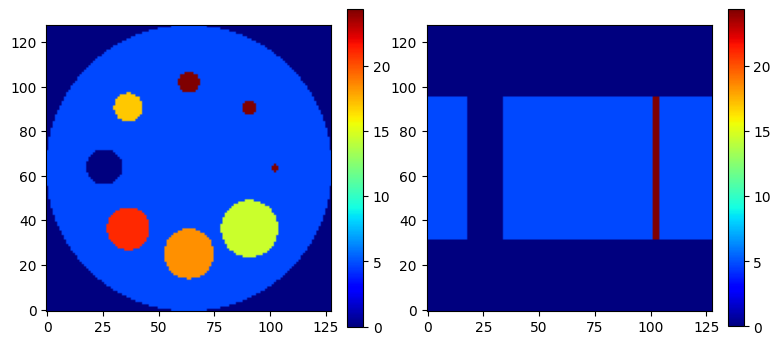

In [9]:
phantom, meta = make_jaszczak_phantom_activity_world(world_shape=(ndim,ndim,ndim), voxel_size_mm=PIXEL_SIZE)
phantom=np.transpose(phantom, (2, 1, 0))
plt.figure(figsize=(9,6))
plt.subplot(1,2,1)
plt.imshow(phantom[int(ndim/2)],origin='lower',cmap='jet')
plt.colorbar(fraction=0.05)
plt.subplot(1,2,2)
plt.imshow(phantom[:,int(ndim/2),:],origin='lower',cmap='jet')
plt.colorbar(fraction=0.05)

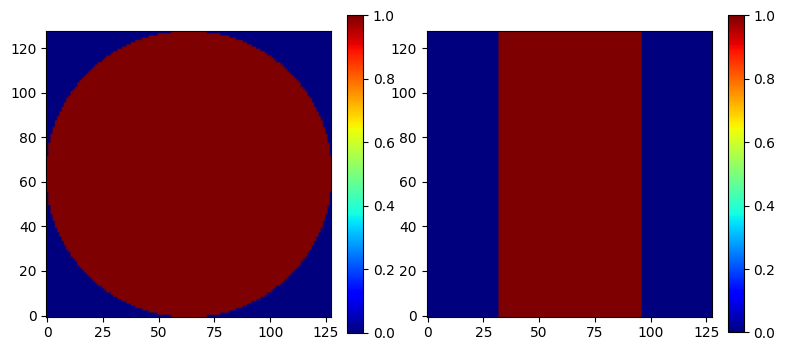

In [11]:
attenuation_map, meta = make_jaszczak_phantom_activity_world(world_shape=(ndim,ndim,ndim), voxel_size_mm=PIXEL_SIZE,add_sources=False,add_cold=False)
attenuation_map=attenuation_map/attenuation_map.max()
attenuation_map=np.transpose(attenuation_map, (2, 1, 0))
plt.figure(figsize=(9,6))
plt.subplot(1,2,1)
plt.imshow(attenuation_map[int(ndim/2)],origin='lower',cmap='jet')
plt.colorbar(fraction=0.05)
plt.subplot(1,2,2)
plt.imshow(attenuation_map[:,int(ndim/2),:].T,origin='lower',cmap='jet')
plt.colorbar(fraction=0.05)

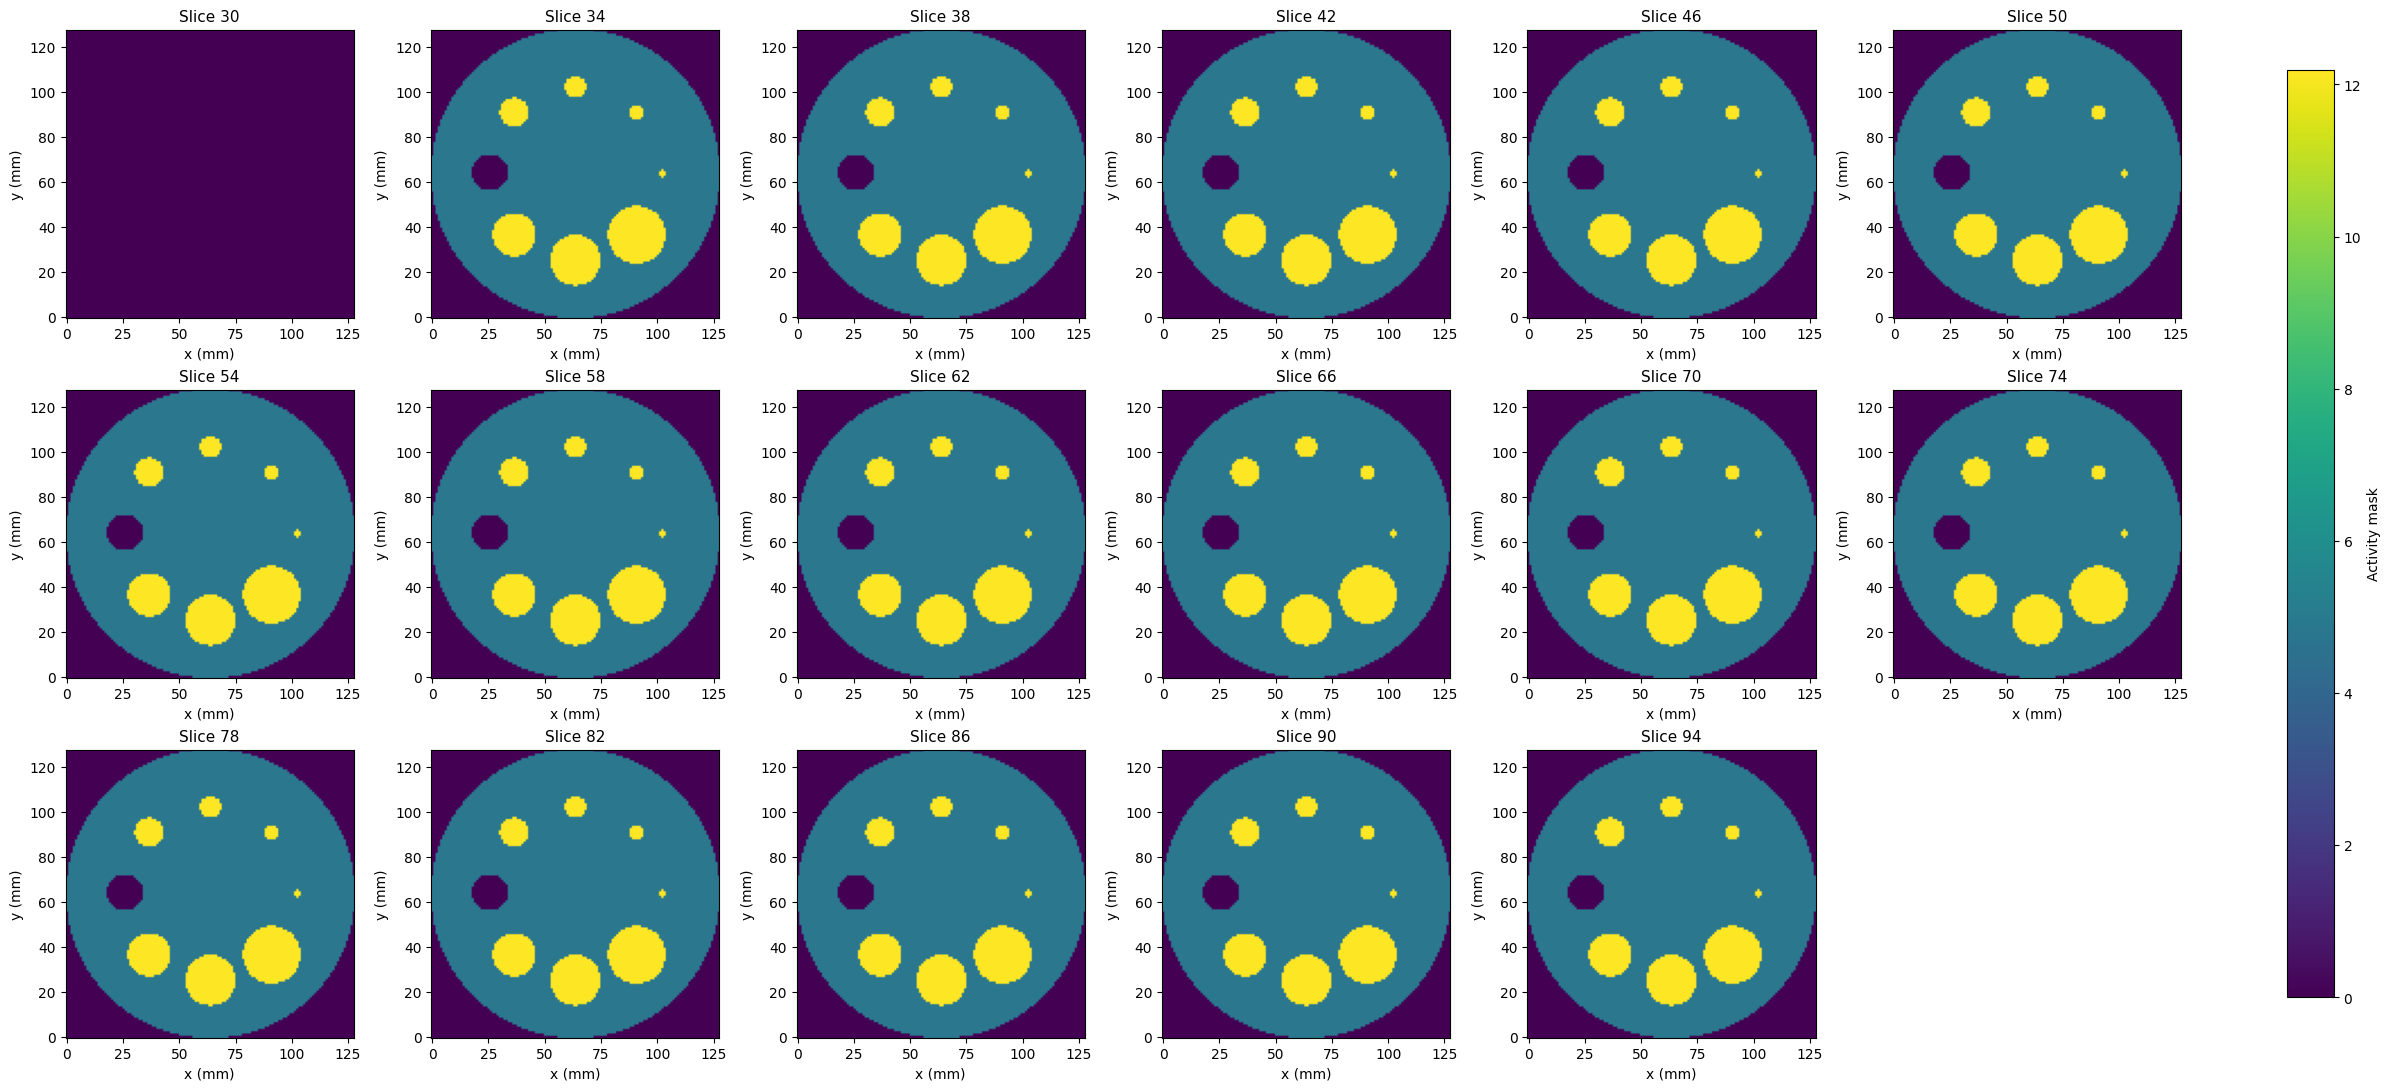

In [12]:
slice_ids = list(range(30, phantom.shape[0] - 30, 4))

ncols = 6
nrows = int(np.ceil(len(slice_ids) / ncols))

fig, axes = plt.subplots(
    nrows, ncols,
    figsize=(4*ncols, 3.6*nrows),
    constrained_layout=True
)

axes = np.atleast_1d(axes).ravel()

vmin = np.min(phantom)
vmax = np.max(phantom)/2.

im = None
for ax, k in zip(axes, slice_ids):
    im = ax.imshow(phantom[k], origin='lower', vmin=vmin, vmax=vmax)
    ax.set_title(f"Slice {k}", fontsize=11)
    ax.set_xlabel("x (mm)")
    ax.set_ylabel("y (mm)")

# Hide unused subplots
for ax in axes[len(slice_ids):]:
    ax.axis("off")

# Single shared colorbar for all used axes
fig.colorbar(im, ax=axes[:len(slice_ids)], label="Activity mask", shrink=0.92)

plt.show()

In [13]:
def write_mhd_raw(image: np.ndarray, out_prefix: str, spacing=(1.0, 1.0, 1.0), origin=(0.0, 0.0, 0.0)):
    """
    Save a 3D numpy array to MetaImage .mhd/.raw (float32, little-endian).
    - image: 3D array (Z, Y, X) or (Y, X) (will auto-promote to Z=1).
    - spacing: (dx, dy, dz) in mm (X, Y, Z order used in header).
    - origin:  (ox, oy, oz) in mm (X, Y, Z order used in header).
    """
    img = np.asarray(image)
    if img.ndim == 2:
        img = img[np.newaxis, ...]  # Z=1
    assert img.ndim == 3, "Image must be 2D or 3D"

    # GATE expects metaimage with Dimension = 3 and ElementSpacing = X Y Z
    # We'll store as float32, little-endian, raw.
    img = img.astype(np.float32, copy=False)

    z, y, x = img.shape
    out_prefix = Path(out_prefix)
    raw_path = out_prefix.with_suffix(".raw")
    mhd_path = out_prefix.with_suffix(".mhd")

    # Write raw binary
    img.tofile(raw_path)

    # Write header
    mhd = []
    mhd.append("ObjectType = Image")
    mhd.append("NDims = 3")
    mhd.append(f"DimSize = {x} {y} {z}")
    mhd.append("ElementType = MET_FLOAT")
    mhd.append(f"ElementSpacing = {spacing[0]} {spacing[1]} {spacing[2]}")  # X Y Z (mm)
    mhd.append(f"Position = {origin[0]} {origin[1]} {origin[2]}")           # optional, X Y Z
    mhd.append("BinaryData = True")
    mhd.append("BinaryDataByteOrderMSB = False")
    mhd.append("CompressedData = False")
    mhd.append(f"ElementDataFile = {raw_path.name}")

    mhd_path.write_text("\n".join(mhd))
    print(f"Wrote {mhd_path} and {raw_path}")



In [14]:
write_mhd_raw(phantom,"phantom",spacing=(PIXEL_SIZE,PIXEL_SIZE,PIXEL_SIZE))

Wrote phantom.mhd and phantom.raw


In [15]:
write_mhd_raw(attenuation_map,"attenuation_map",spacing=(PIXEL_SIZE,PIXEL_SIZE,PIXEL_SIZE))

Wrote attenuation_map.mhd and attenuation_map.raw


# Create (or load) Geometric Projection Matrix (pmatrix_geo)

*Only run for first time. This will generate the geometric matrix using a single cpu. This is a bit slow but it's only needed for the first time. The geometric projection matrix is saved using pk and can be loaded at a later stage.*

In [16]:
angles = np.linspace(0, 360, nangle, endpoint=False)
if not Path(PROJECT_PATH+'/pmatrix_geo.pk').exists():
  N = ndim  # image size: N x N
  pmatrix_geo = np.zeros((len(angles) * nrays, N * N))
  # --- Loop through each pixel and compute its projection ---
  for i in tqdm(range(N * N), desc="Building Radon matrix"):
      # Create image with 1 at pixel i, 0 elsewhere
      basis_img = np.zeros((N, N))
      row, col = divmod(i, N)
      basis_img[row, col] = 1.0

      # Compute projection (sinogram)
      sinogram_temp = radon(basis_img, theta=angles, circle=True)

      # Flatten the sinogram and store as column i
      pmatrix_geo[:, i] = sinogram_temp.T.flatten()

  print(f"Projection matrix shape: {pmatrix_geo.shape}")  # should be (num_angles*num_det_bins, N*N)
  pmatrix_geo=pmatrix_geo/pmatrix_geo.max()
  writedata(pmatrix_geo,PROJECT_PATH+'/pmatrix_geo.pk')
else:
  print('Loading pre-existing geometric projection matrix')
  pmatrix_geo=readdata(PROJECT_PATH+'/pmatrix_geo.pk')

Loading pre-existing geometric projection matrix


In [17]:
pmatrix_geo.shape

(15360, 16384)

# Run GATE10 using gamma photons emitted from phantom with attenuation and scatter according to mu_map.

For each simulated angle, `GATE10.py` creates an output folder named

`output_<angle>`

inside `output_base`.

This folder contains the main GATE simulation outputs for that projection angle, including:

- **projection images** in `.mhd/.raw` format, generated separately for each detector head and for the selected energy window,
- **ROOT files** containing the digitizer outputs (hits, singles, and energy-window collections),
- **a statistics file** (`stats_dual.txt`) summarizing the simulation.

In the present configuration, the most important outputs are the projection images:

- `projection_h1_... .mhd`
- `projection_h2_... .mhd`

which correspond to the simulated projections recorded by the two detector heads.

These projection files are then used in the notebook to construct the GATE-based projection matrix.


Only angles smaller than **180°** are simulated because this is a **dual-head** setup. Each simulation angle produces two projections from detector heads placed **180° apart**, so the range **0°–180°** already covers the full acquisition. Simulating angles beyond **180°** would simply duplicate views already provided by the opposite head.

This will run one projection angle at a time (total of 120 for the examples used) It's a good idea to run this using multiple independent runs.


Main arguments:

- **`angle=a`**: projection angle of the dual-head camera system around the object.
- **`isotope="I123"`**: radionuclide used in the simulation; this determines the emitted gamma-ray spectrum and the corresponding energy windows.
- **`usecollimator=False`**: runs the simulation without a collimator. This is useful here for demonstration and for faster estimation of the system response.
- **`visualize=False`**: disables interactive visualisation during the simulation.
- **`PIXEL_SIZE=PIXEL_SIZE`**: voxel size of the input maps, used also to define the detector projection pixel size.
- **`ndim=ndim`**: number of detector pixels per image dimension, so the simulated projections are of size `ndim × ndim`.
- **`dtheta=0.0`**: angular spread of the emitted photons around the nominal detector direction. Here `0.0` means a single nominal projection direction is used.
- **`nthreads=1`**: number of CPU threads used by the simulation.
- **`activity=0.01`**: source activity in MBq assigned to each of the two voxel sources. A very low value is used here for demonstration in order to keep runtimes manageable.
- **`mu_map_path=.../attenuation_map.mhd`**: path to the voxelized attenuation map used to define the phantom materials in GATE.
- **`source_map_path=.../phantom.mhd`**: path to the voxelized source distribution used to define where activity is present.
- **`output_base=projectpath`**: directory where the output files for each angle are written.


In [ ]:
print(os.cpu_count())

## Generate sinograms

This is where the introduced activity must be realistic

In [18]:
import subprocess
import sys
import time
from pathlib import Path

angles_to_run = [a for a in angles if a < 180.0]
max_workers = 12

running = []
remaining = list(angles_to_run)

while remaining or running:
    # start new jobs until the worker limit is reached
    while remaining and len(running) < max_workers:
        a = remaining.pop(0)

        outdir = Path(PROJECT_PATH) / f"output_{a}"
        outdir.mkdir(parents=True, exist_ok=True)

        logfile = open(outdir / "run.log", "w")

        cmd = [
            sys.executable,
            "-c",
            (
                "import sys; "
                f"sys.path.append(r'{PROJECT_PATH}'); "
                "import GATE10; "
                f"GATE10.run(angle={float(a)}, "
                "isotope='I123', "
                "usecollimator=False, "
                "visualize=False, "
                f"PIXEL_SIZE={PIXEL_SIZE}, "
                f"ndim={ndim}, "
                "dtheta=0.0, "
                "nthreads=1, "
                "activity=1, "
                f"mu_map_path=r'{PROJECT_PATH}/attenuation_map.mhd', "
                f"source_map_path=r'{PROJECT_PATH}/phantom.mhd', "
                f"output_base=r'{PROJECT_PATH}/phantom_data')"
            )
        ]

        print(f"Starting angle {a}")
        p = subprocess.Popen(cmd, stdout=logfile, stderr=logfile)
        running.append((a, p, logfile))

    # check running jobs
    still_running = []
    for a, p, logfile in running:
        ret = p.poll()
        if ret is None:
            still_running.append((a, p, logfile))
        else:
            logfile.close()
            print(f"Angle {a} finished with return code {ret}")
    running = still_running

    # avoid hammering the CPU with constant polling
    time.sleep(1)

print("All runs completed.")

Starting angle 0.0
Starting angle 3.0
Starting angle 6.0
Starting angle 9.0
Starting angle 12.0
Starting angle 15.0
Starting angle 18.0
Starting angle 21.0
Starting angle 24.0
Starting angle 27.0
Starting angle 30.0
Starting angle 33.0
Angle 0.0 finished with return code 0
Starting angle 36.0
Angle 3.0 finished with return code 0
Starting angle 39.0
Angle 6.0 finished with return code 0
Starting angle 42.0
Angle 9.0 finished with return code 0
Starting angle 45.0
Angle 12.0 finished with return code 0
Angle 15.0 finished with return code 0
Starting angle 48.0
Starting angle 51.0
Angle 18.0 finished with return code 0
Starting angle 54.0
Angle 21.0 finished with return code 0
Angle 24.0 finished with return code 0
Angle 30.0 finished with return code 0
Starting angle 57.0
Starting angle 60.0
Starting angle 63.0
Angle 27.0 finished with return code 0
Angle 33.0 finished with return code 0
Starting angle 66.0
Starting angle 69.0
Angle 36.0 finished with return code 0
Starting angle 72.0
A

In [19]:
isotope = "I123"
analysisdirs=[PROJECT_PATH+"phantom_data"]
outname=PROJECT_PATH+'/sinograms_ideal_NC.pk'
dirs = [d for d in os.listdir(analysisdirs[0]) if d.startswith(
    "output_")]
angles = sorted(
    [float(d.split("_")[1]) for d in dirs]
)
print(angles)
print(len(angles))
def writedata(df,fname):
    pk.dump(df,open(fname,'wb'))
    return



# isotope = "I123"
# x="/nvme/scratch/cy15tl1/PERSPECT/GATE10/SL/"
# analysisdirs = [ x+"realistic"+str(i) for i in range(1,123) ]
# ndim = 128
# sinoname="sinogram_no_collimator.pk"

# dirs = [d for d in os.listdir(analysisdirs[0]) if d.startswith("output_")]
# angles = sorted([float(d.split("_")[1]) for d in dirs])

# print(angles)
# print(len(angles))

# def writedata(df, fname):
#     with open(fname, "wb") as f:
#         pk.dump(df, f)

sinograms = np.zeros((2 * len(angles), ndim, ndim), dtype=np.float32)
icount = 0

phantom_width = ndim * PIXEL_SIZE
x_edges = np.linspace(-phantom_width / 2, phantom_width / 2, ndim + 1)
z_edges = np.linspace(-phantom_width / 2, phantom_width / 2, ndim + 1)

for angle in angles:
    print("processing angle", angle)

    for analysisdir in analysisdirs:
    
        outdir = analysisdir + f"/output_{angle}/"
        
        # --- Head 1 ROOT ---
        f_h1 = uproot.open(outdir + f"{isotope}_h1.root")
        tree1 = f_h1["Hits_h1;1"]
        arr1 = tree1.arrays(library="ak")
    
        pid1 = ak.to_numpy(arr1["ParentID"])
        m1 = (pid1 == 0)
    
        hx1 = ak.to_numpy(arr1["PostPosition_X"])[m1]
        hy1 = ak.to_numpy(arr1["PostPosition_Y"])[m1]
        hz1 = ak.to_numpy(arr1["PostPosition_Z"])[m1]
    
        theta = np.deg2rad(float(angle))
        ct, st = np.cos(theta), np.sin(theta)
    
        hx1_rot = ct * hx1 + st * hy1
        # hy1_rot not needed for sinogram
    
        # --- Head 2 ROOT ---
        f_h2 = uproot.open(outdir + f"{isotope}_h2.root")
        tree2 = f_h2["Hits_h2;1"]
        arr2 = tree2.arrays(library="ak")
    
        pid2 = ak.to_numpy(arr2["ParentID"])
        m2 = (pid2 == 0)
    
        hx2 = ak.to_numpy(arr2["PostPosition_X"])[m2]
        hy2 = ak.to_numpy(arr2["PostPosition_Y"])[m2]
        hz2 = ak.to_numpy(arr2["PostPosition_Z"])[m2]
    
        theta = np.deg2rad(float(angle) + 180.0)
        ct, st = np.cos(theta), np.sin(theta)
    
        hx2_rot = ct * hx2 + st * hy2
    
        # ================== sinogram =========================
        # (z_det, x_det) using your chosen edges
        sino1, _, _ = np.histogram2d(hz1, hx1_rot, bins=(z_edges, x_edges))
        sino2, _, _ = np.histogram2d(hz2, hx2_rot, bins=(z_edges, x_edges))
    
        sinograms[icount, :, :] += sino2
        sinograms[icount + len(angles), :, :] += sino1

    icount += 1

writedata(sinograms,outname)
print("Saved: ",outname)


[0.0, 3.0, 6.0, 9.0, 12.0, 15.0, 18.0, 21.0, 24.0, 27.0, 30.0, 33.0, 36.0, 39.0, 42.0, 45.0, 48.0, 51.0, 54.0, 57.0, 60.0, 63.0, 66.0, 69.0, 72.0, 75.0, 78.0, 81.0, 84.0, 87.0, 90.0, 93.0, 96.0, 99.0, 102.0, 105.0, 108.0, 111.0, 114.0, 117.0, 120.0, 123.0, 126.0, 129.0, 132.0, 135.0, 138.0, 141.0, 144.0, 147.0, 150.0, 153.0, 156.0, 159.0, 162.0, 165.0, 168.0, 171.0, 174.0, 177.0]
60
processing angle 0.0
processing angle 3.0
processing angle 6.0
processing angle 9.0
processing angle 12.0
processing angle 15.0
processing angle 18.0
processing angle 21.0
processing angle 24.0
processing angle 27.0
processing angle 30.0
processing angle 33.0
processing angle 36.0
processing angle 39.0
processing angle 42.0
processing angle 45.0
processing angle 48.0
processing angle 51.0
processing angle 54.0
processing angle 57.0
processing angle 60.0
processing angle 63.0
processing angle 66.0
processing angle 69.0
processing angle 72.0
processing angle 75.0
processing angle 78.0
processing angle 81.0
pr

In [20]:
sinograms=readdata('sinograms_ideal_NC.pk')

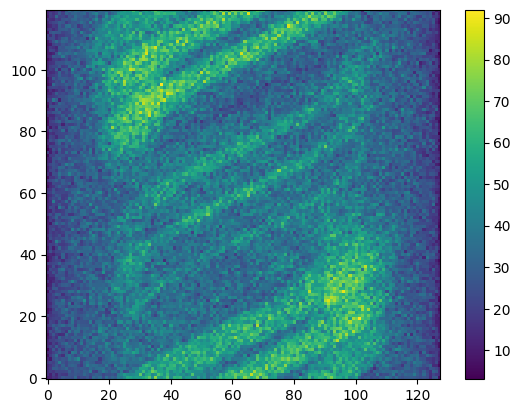

In [21]:
plt.imshow(sinograms[:,64,:],origin='lower')
plt.colorbar()

## Generate projections from GATE output (if not done)

In this case the source is the phantom volume and is unformly generated. The actual source actividies are unknown



In [23]:
import subprocess
import sys
import time
from pathlib import Path

angles_to_run = [a for a in angles if a < 180.0]
max_workers = 12

running = []
remaining = list(angles_to_run)

while remaining or running:
    # start new jobs until the worker limit is reached
    while remaining and len(running) < max_workers:
        a = remaining.pop(0)

        outdir = Path(PROJECT_PATH) / f"output_{a}"
        outdir.mkdir(parents=True, exist_ok=True)

        logfile = open(outdir / "run.log", "w")

        cmd = [
            sys.executable,
            "-c",
            (
                "import sys; "
                f"sys.path.append(r'{PROJECT_PATH}'); "
                "import GATE10; "
                f"GATE10.run(angle={float(a)}, "
                "isotope='I123', "
                "usecollimator=False, "
                "visualize=False, "
                f"PIXEL_SIZE={PIXEL_SIZE}, "
                f"ndim={ndim}, "
                "dtheta=0.0, "
                "nthreads=1, "
                "activity=3, "
                f"mu_map_path=r'{PROJECT_PATH}/attenuation_map.mhd', "
                f"source_map_path=r'{PROJECT_PATH}/attenuation_map.mhd', "
                f"output_base=r'{PROJECT_PATH}/projection_data')"
            )
        ]

        print(f"Starting angle {a}")
        p = subprocess.Popen(cmd, stdout=logfile, stderr=logfile)
        running.append((a, p, logfile))

    # check running jobs
    still_running = []
    for a, p, logfile in running:
        ret = p.poll()
        if ret is None:
            still_running.append((a, p, logfile))
        else:
            logfile.close()
            print(f"Angle {a} finished with return code {ret}")
    running = still_running

    # avoid hammering the CPU with constant polling
    time.sleep(1)

print("All runs completed.")

Starting angle 0.0
Starting angle 3.0
Starting angle 6.0
Starting angle 9.0
Starting angle 12.0
Starting angle 15.0
Starting angle 18.0
Starting angle 21.0
Starting angle 24.0
Starting angle 27.0
Starting angle 30.0
Starting angle 33.0
Angle 0.0 finished with return code 0
Starting angle 36.0
Angle 3.0 finished with return code 0
Starting angle 39.0
Angle 6.0 finished with return code 0
Starting angle 42.0
Angle 9.0 finished with return code 0
Starting angle 45.0
Angle 15.0 finished with return code 0
Starting angle 48.0
Angle 12.0 finished with return code 0
Starting angle 51.0
Angle 21.0 finished with return code 0
Starting angle 54.0
Angle 27.0 finished with return code 0
Starting angle 57.0
Angle 18.0 finished with return code 0
Angle 30.0 finished with return code 0
Starting angle 60.0
Starting angle 63.0
Angle 33.0 finished with return code 0
Starting angle 66.0
Angle 24.0 finished with return code 0
Starting angle 69.0
Angle 36.0 finished with return code 0
Starting angle 72.0
A

In [24]:
isotope = "I123"
analysisdirs=[PROJECT_PATH+"projection_data"]

outname=PROJECT_PATH+'/projections_ideal_NC.pk'

dirs = [d for d in os.listdir(analysisdirs[0]) if d.startswith(
    "output_")]

angles = sorted(
    [float(d.split("_")[1]) for d in dirs]
)

print(angles)
print(len(angles))


def writedata(df,fname):
    pk.dump(df,open(fname,'wb'))
    return



projections = np.zeros((2*len(angles), ndim, ndim, ndim), dtype=np.float32)
icount = 0
for angle in angles:
    print('processing angle ',angle)
    for analysisdir in analysisdirs:

        outdir = analysisdir+f"/output_{angle}/"
        f_h1 = uproot.open(outdir + f"{isotope}_h1.root")
        tree1 = f_h1["Hits_h1;1"]
        arr1 = tree1.arrays(library="ak")
        pid1 = ak.to_numpy(arr1["ParentID"])
        m1 = (pid1 == 0)
        ex1 = ak.to_numpy(arr1["TrackVertexPosition_X"])
        ex1=ex1[m1]
        ey1 = ak.to_numpy(arr1["TrackVertexPosition_Y"])
        ey1=ey1[m1]
        ez1 = ak.to_numpy(arr1["TrackVertexPosition_Z"])
        ez1=ez1[m1]


        # --- Head 2 ROOT ---
        f_h2 = uproot.open(outdir + f"{isotope}_h2.root")
        tree2 = f_h2["Hits_h2;1"]
        arr2 = tree2.arrays(library="ak")
        pid2 = ak.to_numpy(arr2["ParentID"])
        m2 = (pid2 == 0)
        ex2 = ak.to_numpy(arr2["TrackVertexPosition_X"])
        ex2=ex2[m2]
        ey2 = ak.to_numpy(arr2["TrackVertexPosition_Y"])
        ey2=ey2[m2]
        ez2 = ak.to_numpy(arr2["TrackVertexPosition_Z"])
        ez2=ez2[m2]

        phantom_width = ndim * PIXEL_SIZE
        x_edges = np.linspace(-phantom_width/2, phantom_width/2,  ndim + 1)
        y_edges = np.linspace(-phantom_width/2, phantom_width/2, ndim + 1)
        z_edges = np.linspace(-phantom_width/2, phantom_width/2, ndim + 1)
        # ================== projection matrix =========================
        samples_front = np.vstack([ez1, ey1, ex1]).T  # (N,3) as (z, x, y)
        projection1, _ = np.histogramdd(
            samples_front,
            bins=(z_edges, y_edges, x_edges)
        )
        samples_rear = np.vstack([ez2, ey2, ex2]).T
        projection2, _ = np.histogramdd(
            samples_rear,
            bins=(z_edges, y_edges, x_edges)
        )
        projections[icount,             :, :, :] += projection2  # h2
        projections[icount+len(angles), :, :, :] += projection1  # h1

        icount += 1
#    break
projections=projections[::-1]

writedata(projections,outname)


[0.0, 3.0, 6.0, 9.0, 12.0, 15.0, 18.0, 21.0, 24.0, 27.0, 30.0, 33.0, 36.0, 39.0, 42.0, 45.0, 48.0, 51.0, 54.0, 57.0, 60.0, 63.0, 66.0, 69.0, 72.0, 75.0, 78.0, 81.0, 84.0, 87.0, 90.0, 93.0, 96.0, 99.0, 102.0, 105.0, 108.0, 111.0, 114.0, 117.0, 120.0, 123.0, 126.0, 129.0, 132.0, 135.0, 138.0, 141.0, 144.0, 147.0, 150.0, 153.0, 156.0, 159.0, 162.0, 165.0, 168.0, 171.0, 174.0, 177.0]
60
processing angle  0.0
processing angle  3.0
processing angle  6.0
processing angle  9.0
processing angle  12.0
processing angle  15.0
processing angle  18.0
processing angle  21.0
processing angle  24.0
processing angle  27.0
processing angle  30.0
processing angle  33.0
processing angle  36.0
processing angle  39.0
processing angle  42.0
processing angle  45.0
processing angle  48.0
processing angle  51.0
processing angle  54.0
processing angle  57.0
processing angle  60.0
processing angle  63.0
processing angle  66.0
processing angle  69.0
processing angle  72.0
processing angle  75.0
processing angle  78

In [25]:
projections.shape

(120, 128, 128, 128)

In [26]:
projections=readdata("projections_ideal_NC.pk")

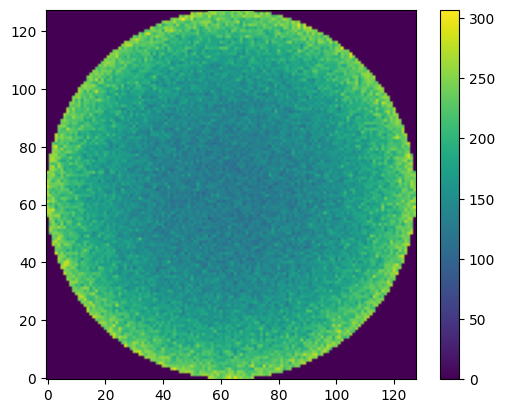

In [27]:
plt.imshow(projections[:,64,:,:].sum(axis=0),origin='lower')
plt.colorbar()

# Application to a specific section

## Create 2D projection matrix

## Projection-matrix model used here

Two projection-matrix models are considered:

- **Geometric matrix (`pmatrix_geo`)**: constructed from a simplified geometric forward model.
- **GATE-based corrected matrix**: obtained by combining the geometric model with Monte Carlo-derived corrections based on attenuation and acquisition physics.

This allows a direct comparison between a simplified system model and a more realistic Monte Carlo-informed model.

In [ ]:
projections=readdata('./projections_ideal_NC.pk')

In [28]:
nslice=64

In [29]:
pmatrix_gate_NC=np.zeros((nangle,nrays,ndim,ndim))
for iang in range(nangle):
    for iray in range(nrays):
        pmatrix_gate_NC[iang,iray,:,:]=(pmatrix_geo.reshape(nangle,nrays,ndim,ndim))[iang,iray,:,:]*\
        projections[iang,nslice,:,:] #.sum(axis=0)
#pmatrix_gate_datscan_WC=pmatrix_gate_datscan_WC/pmatrix_gate_datscan_WC.max()


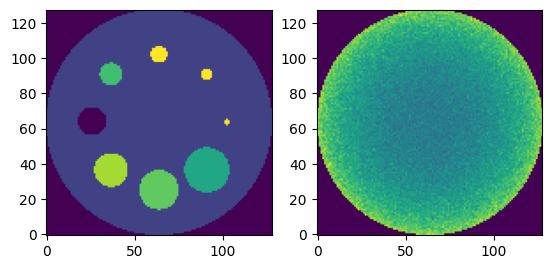

In [30]:
plt.subplot(1,2,1)
plt.imshow(phantom[nslice],origin='lower')
plt.subplot(1,2,2)
plt.imshow(projections.sum(axis=0)[nslice,:,:],origin='lower')

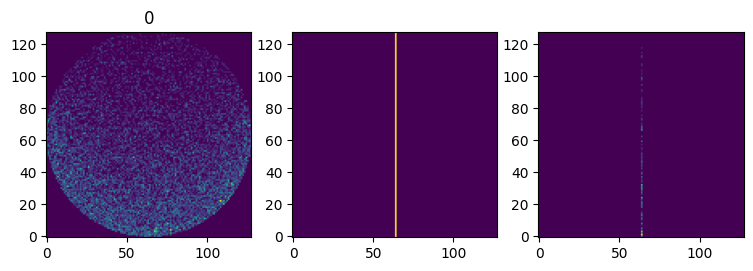

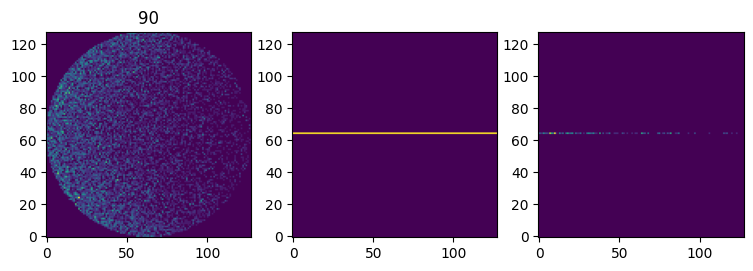

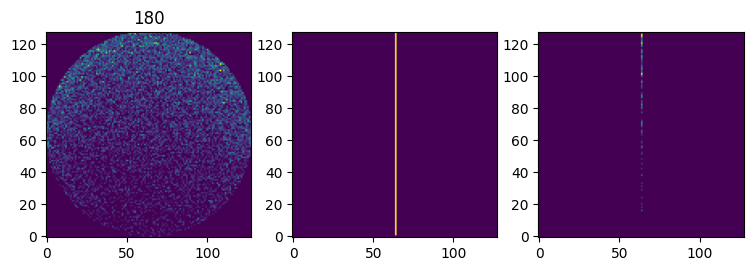

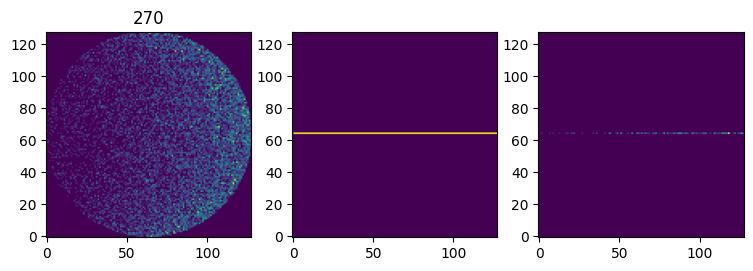

In [31]:
for i in range(nangle):
    if i % 30 ==0:
        plt.figure(figsize=(9,4))
        plt.subplot(1,3,1)
        plt.imshow(projections[i,nslice,:,:],origin='lower')
        plt.title(str(i*3))
        plt.subplot(1,3,2)
        plt.imshow(pmatrix_geo.reshape(nangle,nrays,ndim,ndim)[i,64,:,:],origin='lower')
        plt.subplot(1,3,3)
        plt.imshow(pmatrix_gate_NC[i,64,:,:],origin='lower')
        plt.show()
#plt.imshow(projection2)

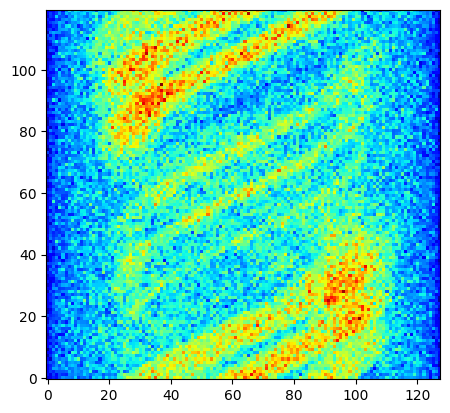

In [32]:
sinogram=sinograms[:120,nslice,:]
plt.imshow(sinogram,origin='lower',cmap='jet')

## Define MLEM and load to gpu

In [33]:

def normimg(img):
    return img/np.nanmean(img)
def printProgressBar(i,max,postText):
    n_bar =40 #size of progress bar
    j= i/max
    sys.stdout.write('\r')
    sys.stdout.write(f"[{'=' * int(n_bar * j):{n_bar}s}] {int(100 * j)}%  {postText}")
    sys.stdout.flush()

def mlem_reconstruction(
    PM,
    sinogram_gpu,
    ndim,
    n_iter=10,
    epsilon=1e-10,
    kernel_params=[],
    *,
    # Optional physical constraints / safeguards
    enforce_positivity=True,          # activity must be >= 0
    mask_outside_fov=True,            # voxels with zero sensitivity forced to 0
    use_proper_sensitivity=True,      # replaces (projection_sum + 1) with max(projection_sum, eps)
    preserve_total_counts=False,       # renormalize image each iter to match total measured counts
    count_relax=0.2
):
    # Sensitivity (a.k.a. normalization image): s = P^T 1
    projection_sum = tf.reduce_sum(PM, axis=0)  # shape: (ndim*ndim,)

    # Optional FOV mask: voxels that are never "seen" by the system matrix
    if mask_outside_fov:
        fov_mask = tf.cast(projection_sum > 0.0, tf.float32)  # 1 where observable
    else:
        fov_mask = tf.ones_like(projection_sum, dtype=tf.float32)

    # Safer denominator: do NOT bias with +1; only protect division by zero
    if use_proper_sensitivity:
        denom = tf.maximum(projection_sum, tf.constant(epsilon, tf.float32))
    else:
        # Keeps your original behavior (not recommended physically)
        denom = projection_sum + 1.0

    def gaussian_kernel(size, sigma):
        ax = np.linspace(-(size // 2), size // 2, size)
        xx, yy = np.meshgrid(ax, ax)
        kernel = np.exp(-0.5 * (xx**2 + yy**2) / sigma**2)
        kernel /= np.sum(kernel)
        return kernel

    if len(kernel_params) > 0:
        kernel = gaussian_kernel(kernel_params[0], kernel_params[1])

    # Initial image (positive)
    reconstructed_image = tf.Variable(np.ones(ndim * ndim), dtype=tf.float32)

    # Apply FOV mask at init if enabled
    if mask_outside_fov:
        reconstructed_image.assign(reconstructed_image * fov_mask)

    start_time = time.time()
    chi2_loss = -1.0

    # For optional global renormalization (heuristic; only enable if you want it)
    y_sum = tf.reduce_sum(tf.cast(sinogram_gpu, tf.float32))

    for iter in range(n_iter):
        printProgressBar(iter, n_iter, '' + str(chi2_loss))

        # Optional smoothing (heuristic regularization)
        if len(kernel_params) > 0:
            rimage = reconstructed_image.numpy()
            temp = convolve(np.reshape(rimage, (ndim, ndim)), kernel, mode='reflect').ravel()
            reconstructed_image.assign(temp)

        # Physical constraint: non-negativity
        if enforce_positivity:
            reconstructed_image.assign(tf.maximum(reconstructed_image, 0.0))

        # Physical constraint: zero outside FOV (voxels with zero sensitivity)
        if mask_outside_fov:
            reconstructed_image.assign(reconstructed_image * fov_mask)

        # Forward projection
        forward_projection = tf.linalg.matvec(PM, reconstructed_image)
        forward_projection = tf.maximum(forward_projection, tf.constant(epsilon, tf.float32))

        # Compute ratio
        ratio = sinogram_gpu / forward_projection

        # Back-projection
        back_projection = tf.linalg.matvec(tf.transpose(PM), ratio)

        # MLEM update with correct/safe denominator
        reconstructed_image.assign(reconstructed_image * (back_projection / denom))

        # Optional global renormalization to match total measured counts
        # (heuristic; can be useful if your PM is not strictly probability-normalized)
        if preserve_total_counts:
            fp_sum = tf.reduce_sum(tf.linalg.matvec(PM, reconstructed_image))
            fp_sum = tf.maximum(fp_sum, tf.constant(epsilon, tf.float32))
            alpha = y_sum / fp_sum
            # softened update: alpha**count_relax
            reconstructed_image.assign(reconstructed_image * tf.pow(alpha, count_relax))
        # Monitor (your chi2-like metric)
        chi2_loss = tf.reduce_mean((forward_projection - sinogram_gpu) ** 2 / (sinogram_gpu + epsilon))

    # Final loss
    forward_projection_final = tf.linalg.matvec(PM, reconstructed_image)
    chi2_loss = tf.reduce_mean((forward_projection_final - sinogram_gpu) ** 2 / (sinogram_gpu + epsilon))

    reconstructed_image = tf.reshape(reconstructed_image, (ndim, ndim))
    cpu_time = time.time() - start_time

    print()
    print('final chi2_loss =', chi2_loss.numpy())
    return reconstructed_image, chi2_loss, cpu_time




In [34]:
pmatrix_geo.shape

(15360, 16384)

In [35]:
pmatrix_geo_gpu = tf.constant(pmatrix_geo, dtype=tf.float32)

In [36]:
pmatrix_gate_NC=pmatrix_gate_NC.reshape(nangle*nrays,ndim**2)
pmatrix_gate_NC=pmatrix_gate_NC/pmatrix_gate_NC.max()

In [37]:
pmatrix_gate_NC_gpu=tf.constant(pmatrix_gate_NC,dtype=tf.float32)

In [38]:
sinogram_gpu = tf.constant(sinogram.ravel(), dtype=tf.float32)

## Reconstruction without correction

In [39]:
reconstructed_image0_MLEM,error,t = mlem_reconstruction(pmatrix_geo_gpu,sinogram_gpu,ndim,n_iter=100,epsilon=0.0001,kernel_params=[])
print('time=',t)

[======================================= ] 99%  tf.Tensor(1.2782899, shape=(), dtype=float32)
final chi2_loss = 1.2760533
time= 3.953619956970215


Text(0.5, 1.0, 'Reconstructed image')

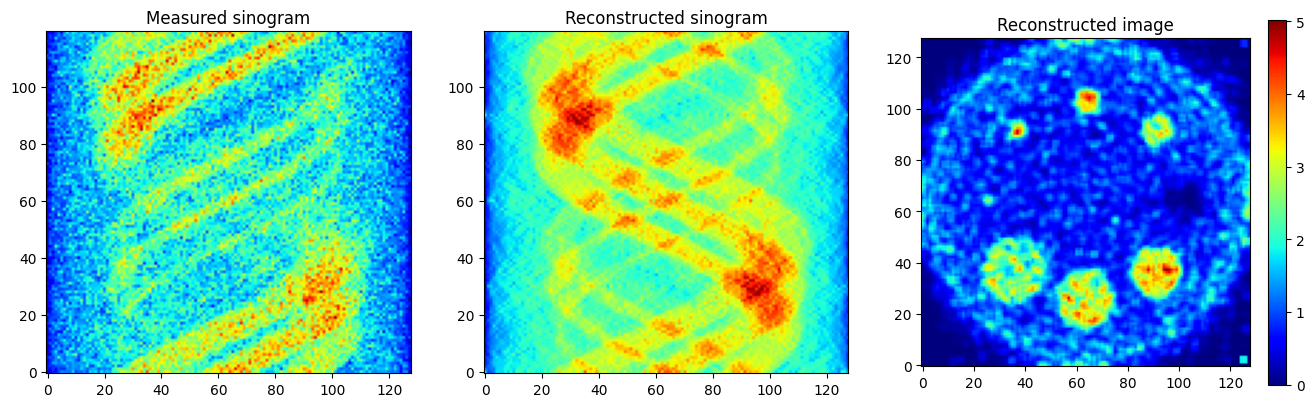

In [40]:
plt.figure(figsize=(16,8))
plt.subplot(1,3,1)
vmax=200
plt.imshow(sinogram,cmap='jet',origin='lower') #,vmax=vmax)
plt.title('Measured sinogram')
plt.subplot(1,3,2)
rsinogram0=np.dot(pmatrix_geo.reshape(nrays*nangle,ndim*ndim),(reconstructed_image0_MLEM.numpy()).ravel())
r=rsinogram0.mean()
plt.title('Reconstructed sinogram')
#print(r)
plt.imshow(rsinogram0.reshape(nangle,nrays),cmap='jet',origin='lower') #,vmax=vmax)
plt.subplot(1,3,3)
plt.imshow(smear(normimg(reconstructed_image0_MLEM),1),cmap='jet',origin='lower')
plt.colorbar(fraction=0.05)
plt.title('Reconstructed image')

## Reconstruction with GATE correction

In [41]:
reconstructed_image1_MLEM,error,t = mlem_reconstruction(pmatrix_gate_NC_gpu,sinogram_gpu,ndim,n_iter=100,epsilon=0.0001,kernel_params=[])
print('time=',t)

[======================================= ] 99%  tf.Tensor(0.8269705, shape=(), dtype=float32))
final chi2_loss = 0.8241998
time= 3.7027227878570557


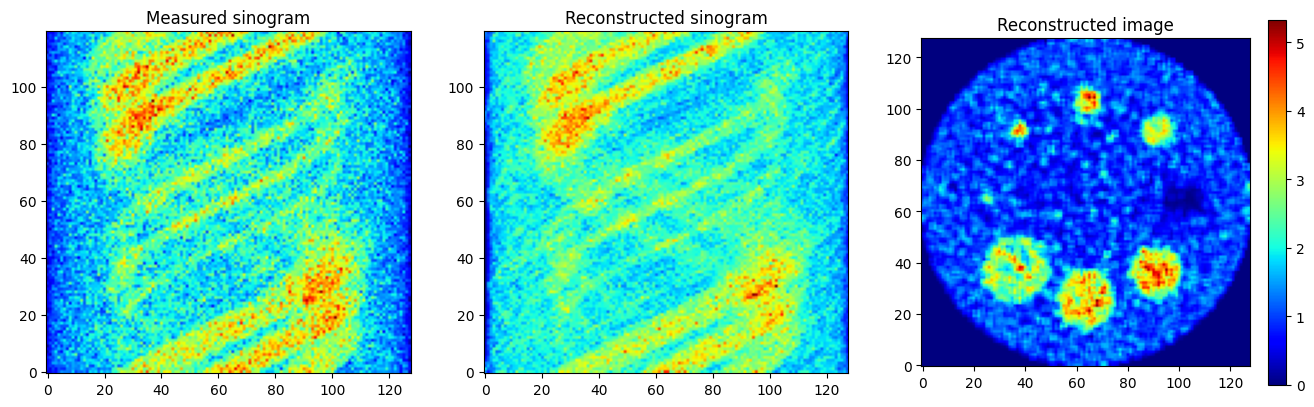

In [42]:
plt.figure(figsize=(16,8))
plt.subplot(1,3,1)
vmax=200
plt.imshow(sinogram,cmap='jet',origin='lower') #,vmax=vmax)
plt.title('Measured sinogram')
plt.subplot(1,3,2)
rsinogram1=np.dot(pmatrix_gate_NC.reshape(nrays*nangle,ndim*ndim),(reconstructed_image0_MLEM.numpy()).ravel())
r=rsinogram1.mean()
plt.title('Reconstructed sinogram')
#print(r)
plt.imshow(rsinogram1.reshape(nangle,nrays),cmap='jet',origin='lower') #,vmax=vmax)
plt.subplot(1,3,3)
plt.imshow(smear(normimg(reconstructed_image1_MLEM),1),cmap='jet',origin='lower')
plt.title('Reconstructed image')
plt.colorbar(fraction=0.05)